# BEBM PTT: SiLU NoW2 vs SiLU W2

Comparison notebook for the two current PTT trainings. Use `ACTIVE_RUN` to inspect one archive in detail; the early summary cell compares both.


In [17]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from rbms.io import load_params
from rbms.utils import get_saved_updates

plt.rcParams["figure.dpi"] = 120
device = "cpu"
dtype = torch.float32

## Configuration

In [18]:
PTT_RUNS = {
    "PTT SiLU NoW2 | DMALA1000 | lr 1 | partial 500k": Path(
        "BEBM_SiLUNoW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1_500k.h5"
    ),
    "PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k": Path(
        "BEBM_SiLUW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1e-1_500k.h5"
    ),
}

REMOTE_PROGRESS_AT_COLLECTION = {
    "PTT SiLU NoW2 | DMALA1000 | lr 1 | partial 500k": "running remotely, log update ~66787, saved checkpoint 65407",
    "PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k": "running remotely, log update/saved checkpoint 33879",
}

# Change this line to inspect the W2 archive in the single-run cells below.
ACTIVE_RUN = "PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k"

filename = PTT_RUNS[ACTIVE_RUN]
train_filename = Path("data/MNIST_train.h5")
test_filename = Path("data/MNIST_test.h5")

max_ll_samples = 10000
rng = np.random.default_rng(0)

for label, path in PTT_RUNS.items():
    print(label)
    print("  file:", path)
    print("  exists:", path.exists())
    print("  remote:", REMOTE_PROGRESS_AT_COLLECTION.get(label, "not recorded"))

print("\nACTIVE_RUN:", ACTIVE_RUN)
print("active file:", filename)

assert filename.exists(), filename
assert train_filename.exists(), train_filename
assert test_filename.exists(), test_filename


PTT SiLU NoW2 | DMALA1000 | lr 1 | partial 500k
  file: BEBM_SiLUNoW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1_500k.h5
  exists: True
  remote: running remotely, log update ~66787, saved checkpoint 65407
PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k
  file: BEBM_SiLUW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1e-1_500k.h5
  exists: True
  remote: running remotely, log update/saved checkpoint 33879

ACTIVE_RUN: PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k
active file: BEBM_SiLUW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1e-1_500k.h5


## Helpers

In [19]:
def decode_h5_value(x):
    if isinstance(x, np.ndarray) and x.shape == ():
        x = x.item()
    if isinstance(x, np.generic):
        x = x.item()
    if isinstance(x, bytes):
        return x.decode()
    return x


def read_group_scalars(group):
    values = {}
    for key, value in group.items():
        if isinstance(value, h5py.Dataset):
            arr = value[()]
            if getattr(arr, "shape", None) == ():
                values[key] = decode_h5_value(arr)
            elif np.size(arr) == 1:
                values[key] = np.asarray(arr).reshape(-1)[0]
            else:
                values[key] = arr
    return values


def image_shape(num_visibles):
    side = int(np.sqrt(num_visibles))
    if side * side == num_visibles:
        return side, side
    return 1, num_visibles


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_samples(path, max_samples=None):
    with h5py.File(path, "r") as f:
        n = f["samples"].shape[0]
        if max_samples is None or max_samples >= n:
            data = np.asarray(f["samples"], dtype=np.float32)
        else:
            idx = np.sort(rng.choice(n, size=max_samples, replace=False))
            data = np.asarray(f["samples"][idx], dtype=np.float32)
    return data


def get_w1_b1(params):
    energy = getattr(params, "energy", None)
    if energy is not None and hasattr(energy, "net"):
        for layer in energy.net:
            if isinstance(layer, torch.nn.Linear):
                return to_numpy(layer.weight), to_numpy(layer.bias)
    if energy is not None and hasattr(energy, "weight"):
        return to_numpy(energy.weight).T, to_numpy(energy.hbias)
    if hasattr(params, "weight_matrix"):
        return to_numpy(params.weight_matrix).T, to_numpy(params.hbias)
    raise TypeError("Cannot extract W1 and b1 from this model.")


def plot_image_grid(vectors, title, n_cols=8, max_items=64, cmap="gray"):
    vectors = np.asarray(vectors)
    n_items = min(max_items, vectors.shape[0])
    h, w = image_shape(vectors.shape[1])
    n_cols = min(n_cols, n_items)
    n_rows = int(np.ceil(n_items / n_cols))
    images = vectors[:n_items].reshape(n_items, h, w)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.25 * n_cols, 1.25 * n_rows))
    axes = np.asarray(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for i in range(n_items):
        im = images[i]
        if cmap != "gray":
            scale = max(np.abs(im).max(), 1e-12)
            axes[i].imshow(im / scale, cmap=cmap, vmin=-1, vmax=1)
        else:
            axes[i].imshow(im, cmap=cmap)
        axes[i].set_title(str(i), fontsize=7)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def compute_ll_subset(params, data, log_z, batch_size=2048):
    values = []
    with torch.no_grad():
        for start in range(0, data.shape[0], batch_size):
            batch = torch.as_tensor(data[start:start + batch_size], device=params.device, dtype=params.dtype)
            values.append((-params.compute_energy_visibles(batch) - log_z).detach().cpu())
    return torch.cat(values).mean().item()


def sample_from_model(params, start_v=None, num_samples=64, n_steps=100, kernel_params=None):
    if kernel_params is None:
        kernel_params = {"alpha": 0.5}
    if start_v is None:
        chains = params.init_chains(num_samples=num_samples)
    else:
        chains = params.init_chains(num_samples=start_v.shape[0], start_v=start_v)
    chains = params.sample_state(chains=chains, n_steps=n_steps, kernel="dmala", kernel_params=kernel_params)
    return to_numpy(chains["visible"])

## All PTT Run Snapshots


In [20]:
def summarize_ptt_archive(path):
    out = {"path": str(path)}
    with h5py.File(path, "r") as f:
        updates = sorted(int(k.split("_")[1]) for k in f.keys() if k.startswith("update_"))
        out["n_saved"] = len(updates)
        out["first_update"] = int(updates[0])
        out["last_update"] = int(updates[-1])
        out["model_type"] = decode_h5_value(f["model_type"][()]) if "model_type" in f else None

        if "ptt_args" in f:
            out["ptt_args"] = read_group_scalars(f["ptt_args"])
        else:
            out["ptt_args"] = {}

        last_group = f[f"update_{updates[-1]}"]
        out["log_z"] = float(last_group["log_z"][()]) if "log_z" in last_group else np.nan
        lr = last_group["learning_rate"][()] if "learning_rate" in last_group else np.asarray([np.nan])
        out["learning_rate"] = float(np.asarray(lr).reshape(-1)[0])
        out["flags"] = list(last_group["flags"].keys()) if "flags" in last_group else []

        params = last_group["params"]
        if "visible_field" in params:
            vf = np.asarray(params["visible_field"])
            out["visible_field_norm"] = float(np.linalg.norm(vf))
            out["visible_field_max_abs"] = float(np.max(np.abs(vf)))
        if "net.0.weight" in params:
            w1 = np.asarray(params["net.0.weight"])
            s = np.linalg.svd(w1, compute_uv=False)
            out["w1_top_singular"] = float(s[0])
            out["w1_rank1_energy"] = float(s[0] ** 2 / np.sum(s ** 2))
            out["w1_fro"] = float(np.linalg.norm(w1))
        if "net.2.weight" in params:
            w2 = np.asarray(params["net.2.weight"])
            out["w2_norm"] = float(np.linalg.norm(w2))
            out["w2_max_abs"] = float(np.max(np.abs(w2)))
        if "parallel_chains" in f:
            chains = np.asarray(f["parallel_chains"])
            out["chains_shape"] = chains.shape
            out["chains_mean"] = float(chains.mean())

    return out

ptt_summaries = {label: summarize_ptt_archive(path) for label, path in PTT_RUNS.items()}

for label, summary in ptt_summaries.items():
    print("\n" + label)
    print("  remote:", REMOTE_PROGRESS_AT_COLLECTION.get(label, "not recorded"))
    for key, value in summary.items():
        if key == "ptt_args":
            compact = {k: value[k] for k in ["increment", "num_swaps", "target_n_model", "max_n_model"] if k in value}
            print("  ptt_args:", compact)
        elif isinstance(value, float):
            print(f"  {key}: {value:.6g}")
        else:
            print(f"  {key}: {value}")



PTT SiLU NoW2 | DMALA1000 | lr 1 | partial 500k
  remote: running remotely, log update ~66787, saved checkpoint 65407
  path: BEBM_SiLUNoW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1_500k.h5
  n_saved: 148
  first_update: 1
  last_update: 65407
  model_type: BEBM
  ptt_args: {'increment': 1000, 'num_swaps': 1, 'target_n_model': 2, 'max_n_model': 2}
  log_z: -324.47
  learning_rate: 0.5
  flags: ['checkpoint', 'ptt']
  visible_field_norm: 237.407
  visible_field_max_abs: 18.7673
  w1_top_singular: 292.436
  w1_rank1_energy: 0.0109653
  w1_fro: 2792.68
  chains_shape: (2000, 784)
  chains_mean: 0.132337

PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k
  remote: running remotely, log update/saved checkpoint 33879
  path: BEBM_SiLUW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1e-1_500k.h5
  n_saved: 163
  first_update: 1
  last_update: 33879
  model_type: BEBM
  ptt_args: {'increment': 1000, 'num_swaps': 1, 'target_n_model': 2, 'max_n_model': 2}
  log_z: 189.823
  learning_rate: 0.003125
  flags: ['p

## Archive summary

In [21]:
saved_updates = get_saved_updates(str(filename))
print("ACTIVE_RUN:", ACTIVE_RUN)
print("filename:", filename)
print("num saved updates:", len(saved_updates))
print("first updates:", saved_updates[:10])
print("last updates:", saved_updates[-10:])

with h5py.File(filename, "r") as f:
    print("model_type:", decode_h5_value(f["model_type"][()]))
    for group_name in ["hyperparameters", "train_args", "sampling_args", "ptt_args"]:
        if group_name in f:
            print("\n" + group_name)
            for key, value in read_group_scalars(f[group_name]).items():
                print(" ", key, ":", value)
    if "sampler" in f:
        sampler = f["sampler"]
        print("\nsampler keys:", list(sampler.keys())[:20], "...")
        print("num_models:", sampler["num_models"][()] if "num_models" in sampler else None)
        print("reservoir shape:", sampler["reservoir"].shape if "reservoir" in sampler else None)


ACTIVE_RUN: PTT SiLU W2 | DMALA1000 | lr 0.1 | partial 500k
filename: BEBM_SiLUW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1e-1_500k.h5
num saved updates: 163
first updates: [ 1  2  3  4  5  6  7  8  9 10]
last updates: [25529 26103 26924 27873 28346 29764 30056 31782 31917 33879]
model_type: BEBM

hyperparameters
  energy_type : b'mlp'
  filename : b'BEBM_SiLUW2_MNIST_PTT_DMALA1000_h500_init2e-3_lr1e-1_500k.h5'
  num_chains : 2000
  num_hiddens : 500
  num_visibles : 784

train_args
  batch_size : 2000
  learning_rate : 0.1
  max_lr : 10
  optim : b'sgd'
  training_type : b'pcd'

sampling_args
  beta : 1.0
  gibbs_steps : 1

ptt_args
  full_sampler : False
  increment : 1000
  max_n_model : 2
  n_sample_steps : 10
  num_steps_annealing : 100
  num_swaps : 1
  patience : 3
  reservoir_size : 20000
  target_acc_rate : 0.25
  target_n_model : 2

sampler keys: ['full_sampler', 'increment', 'log_z_init', 'max_n_model', 'model_type', 'n_sample_steps', 'name', 'net.0.bias__0', 'net.0.bias__1', 'n

## Saved training curves

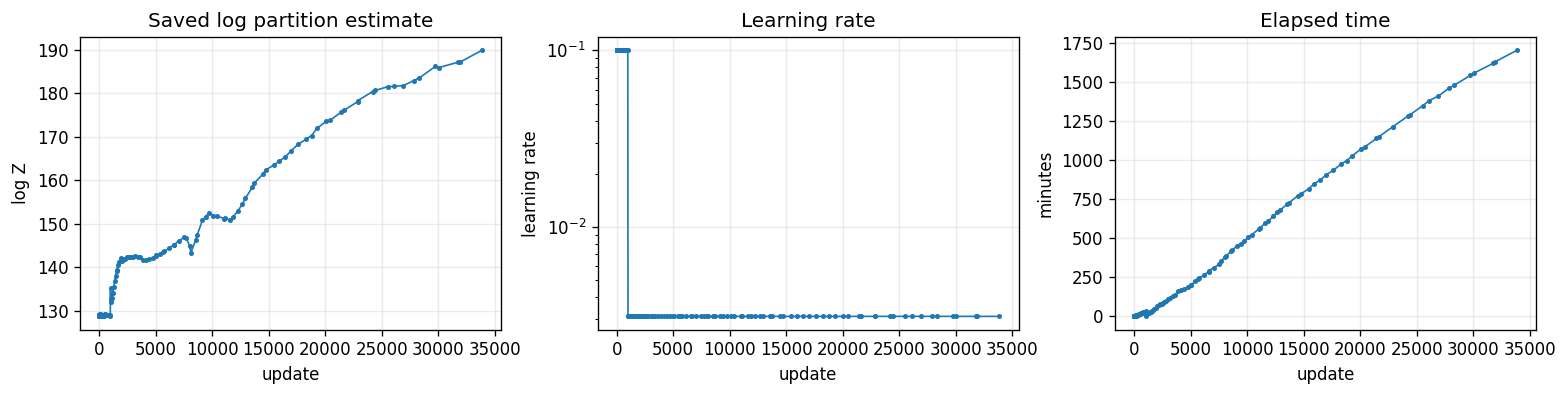

In [22]:
updates = []
times = []
log_zs = []
learning_rates = []
flags = []

with h5py.File(filename, "r") as f:
    for update in saved_updates:
        group = f[f"update_{int(update)}"]
        updates.append(int(update))
        times.append(float(group["time"][()]) if "time" in group else np.nan)
        log_zs.append(float(group["log_z"][()]) if "log_z" in group else np.nan)
        lr = group["learning_rate"][()] if "learning_rate" in group else np.asarray([np.nan])
        learning_rates.append(float(np.asarray(lr).reshape(-1)[0]))
        flags.append(list(group["flags"].keys()) if "flags" in group else [])

updates = np.asarray(updates)
times = np.asarray(times)
log_zs = np.asarray(log_zs)
learning_rates = np.asarray(learning_rates)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(updates, log_zs, marker="o", markersize=2, linewidth=1)
axes[0].set_xlabel("update")
axes[0].set_ylabel("log Z")
axes[0].set_title("Saved log partition estimate")
axes[0].grid(alpha=0.25)

axes[1].plot(updates, learning_rates, marker="o", markersize=2, linewidth=1)
axes[1].set_xlabel("update")
axes[1].set_ylabel("learning rate")
axes[1].set_title("Learning rate")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)

axes[2].plot(updates, times / 60, marker="o", markersize=2, linewidth=1)
axes[2].set_xlabel("update")
axes[2].set_ylabel("minutes")
axes[2].set_title("Elapsed time")
axes[2].grid(alpha=0.25)
fig.tight_layout()

## Log-likelihood on train/test subsets

final train LL: -102.60062408447266
final test LL: -101.6858139038086


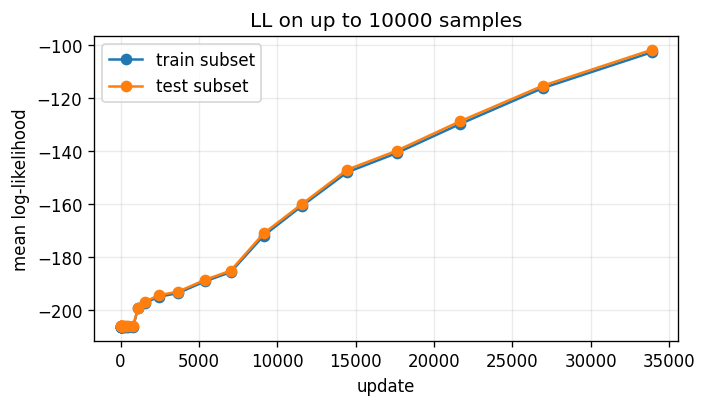

In [23]:
train_data = load_samples(train_filename, max_samples=max_ll_samples)
test_data = load_samples(test_filename, max_samples=max_ll_samples)

ll_updates = saved_updates[np.linspace(0, len(saved_updates) - 1, min(25, len(saved_updates))).astype(int)]
ll_train = []
ll_test = []

with h5py.File(filename, "r") as f:
    for update in ll_updates:
        params = load_params(str(filename), int(update), device=device, dtype=dtype)
        log_z = float(f[f"update_{int(update)}"]["log_z"][()])
        ll_train.append(compute_ll_subset(params, train_data, log_z))
        ll_test.append(compute_ll_subset(params, test_data, log_z))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ll_updates, ll_train, marker="o", label="train subset")
ax.plot(ll_updates, ll_test, marker="o", label="test subset")
ax.set_xlabel("update")
ax.set_ylabel("mean log-likelihood")
ax.set_title(f"LL on up to {max_ll_samples} samples")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

print("final train LL:", ll_train[-1])
print("final test LL:", ll_test[-1])

## Final model and permanent chains

final update: 33879
final log_z: 189.823486328125
chains shape: (2000, 784)
chains mean pixel: 0.13151786


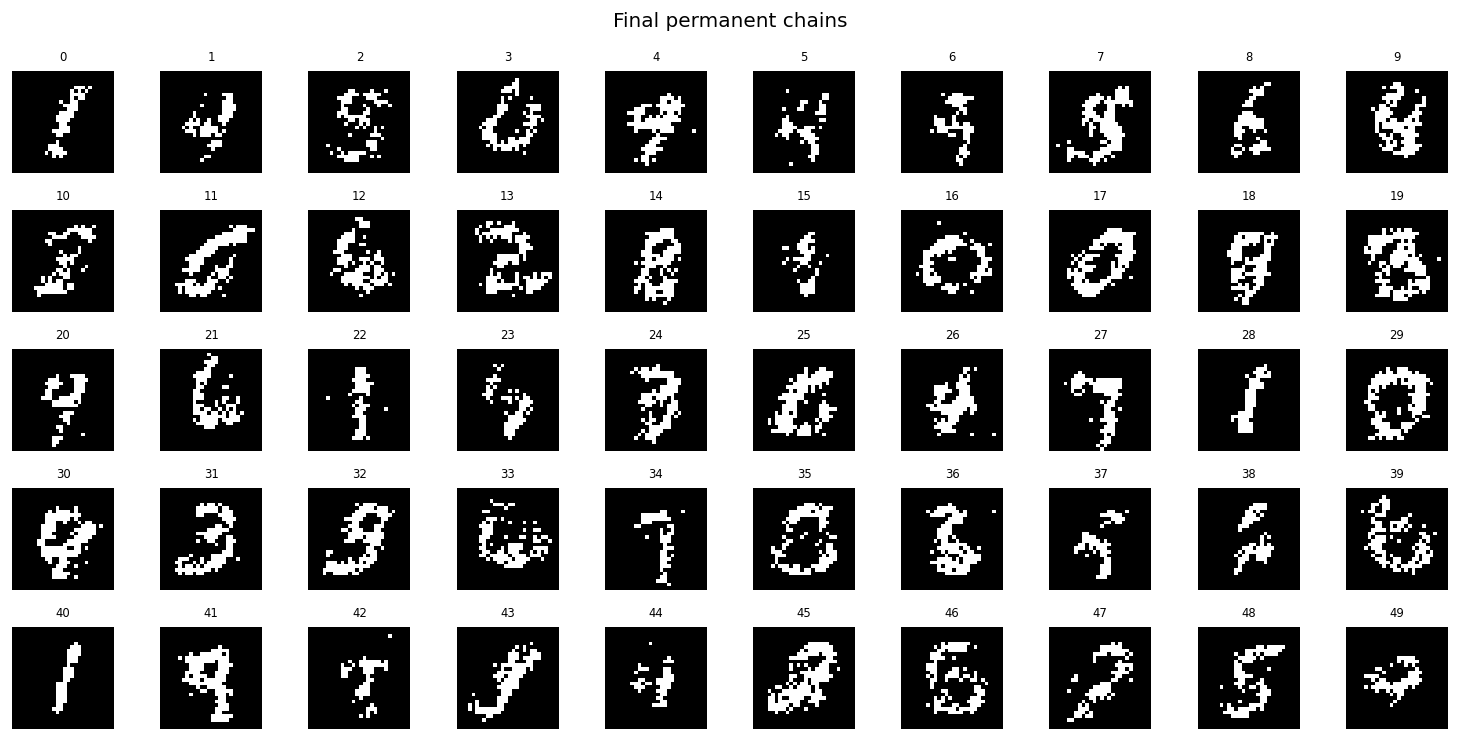

In [24]:
final_update = int(saved_updates[-1])
params = load_params(str(filename), final_update, device=device, dtype=dtype)
with h5py.File(filename, "r") as f:
    chains_visible = np.asarray(f["parallel_chains"], dtype=np.float32)
    final_log_z = float(f[f"update_{final_update}"]["log_z"][()])

print("final update:", final_update)
print("final log_z:", final_log_z)
print("chains shape:", chains_visible.shape)
print("chains mean pixel:", chains_visible.mean())

plot_image_grid(chains_visible, title="Final permanent chains", n_cols=10, max_items=50, cmap="gray");

model PCA eigenvalues: [4.5809765 3.728961  2.9939144 2.7821167 2.3368318 1.9525695 1.6256535
 1.4737236 1.3253688 1.1864465]
model PCA vectors shape: (784, 784)


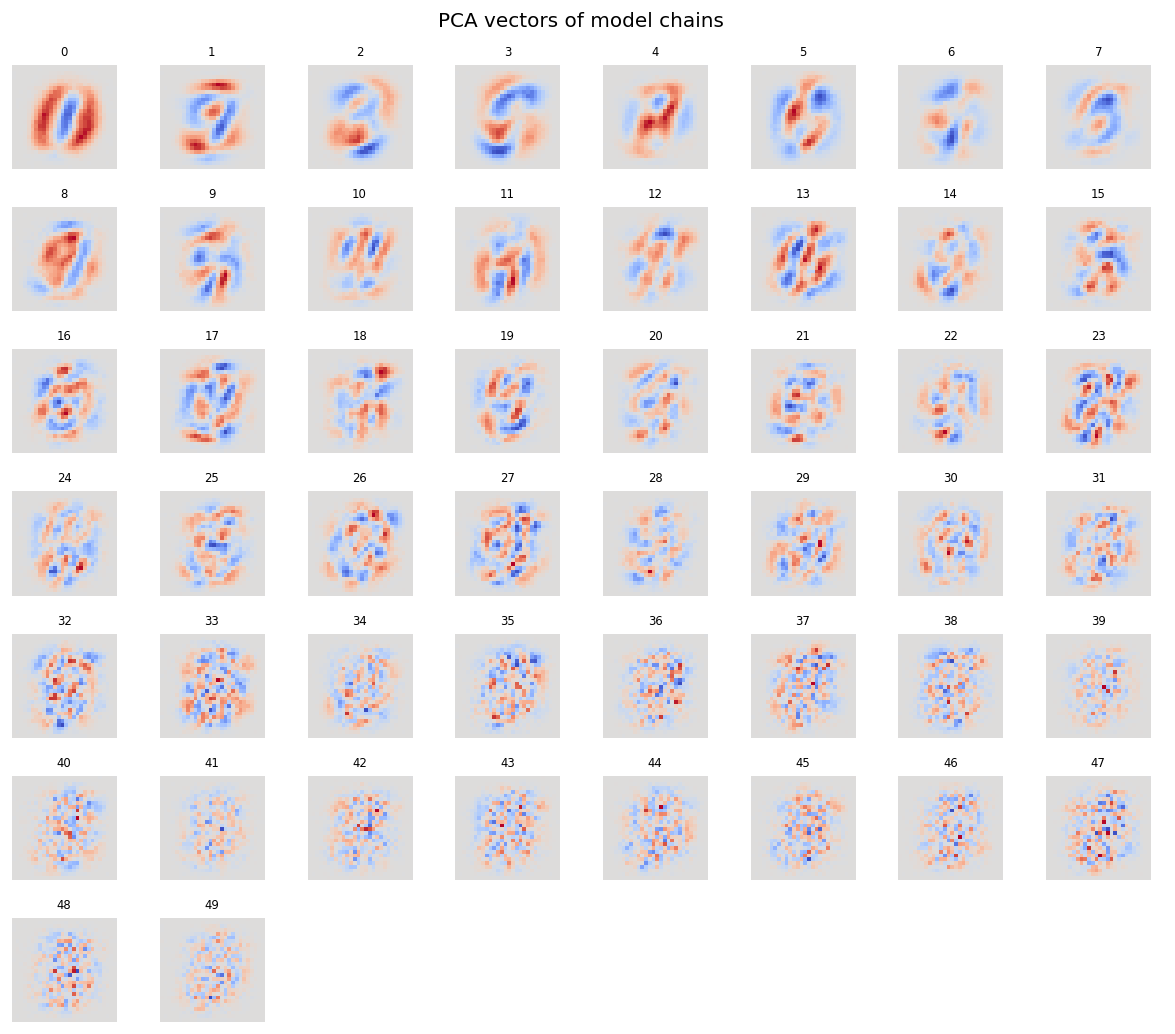

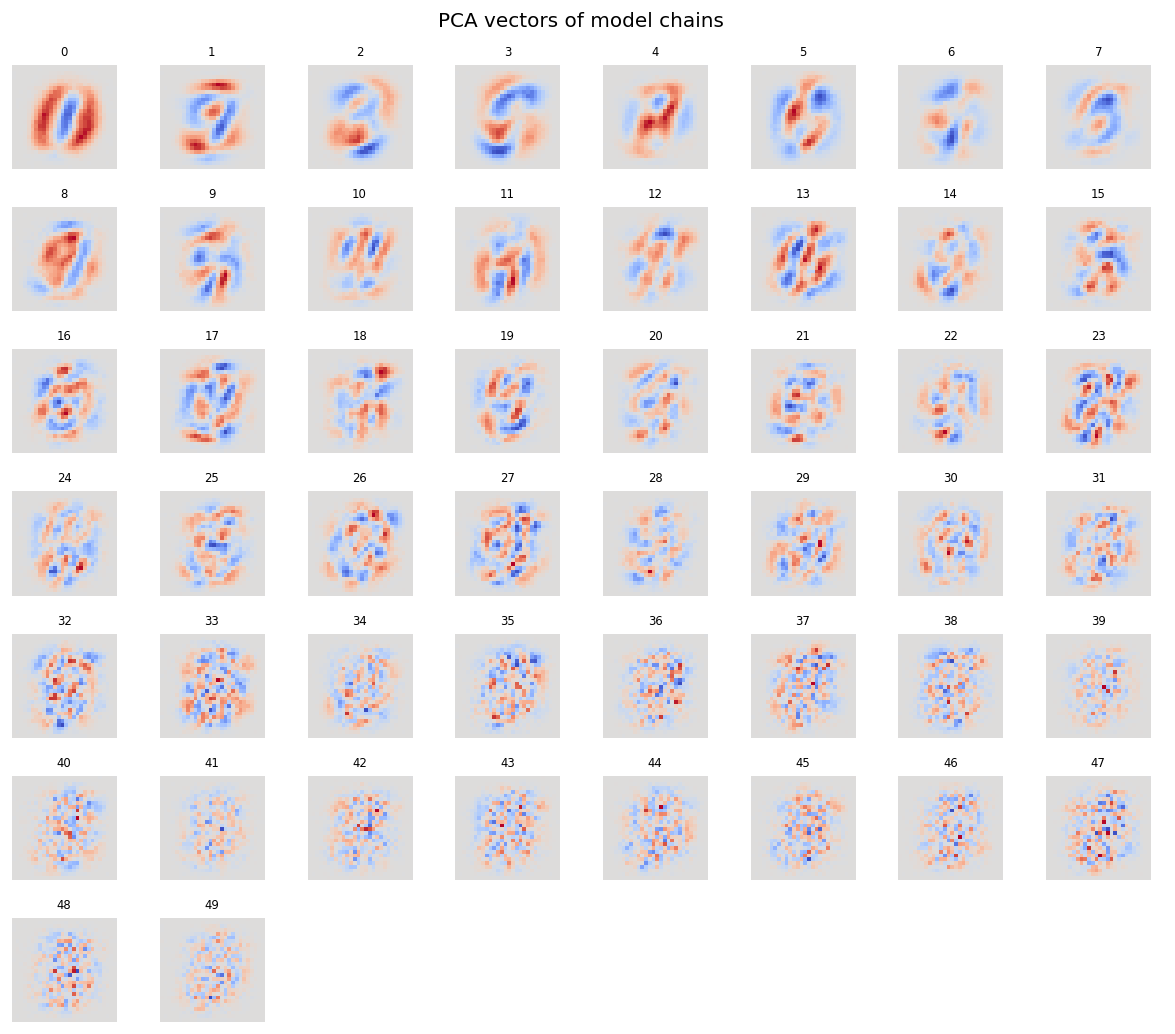

In [25]:
# PCA vectors of the model samples / chains
# Uses chains_visible with shape (n_chains, n_visible)
import numpy as np

X_model = np.asarray(chains_visible, dtype=np.float32)

model_mean = X_model.mean(axis=0)
X_model_centered = X_model - model_mean

C_model = X_model_centered.T @ X_model_centered / (X_model_centered.shape[0] - 1)

eigvals_model, eigvecs_model = np.linalg.eigh(C_model)
order = np.argsort(eigvals_model)[::-1]

eigvals_model = eigvals_model[order]
eigvecs_model = eigvecs_model[:, order]

print("model PCA eigenvalues:", eigvals_model[:10])
print("model PCA vectors shape:", eigvecs_model.shape)

plot_image_grid(
    eigvecs_model.T[:50],
    title="PCA vectors of model chains",
    cmap="coolwarm",
)


## Sampling

Selected updates for PTT: [    1  1001  1014  1540  2537  4992  5617  6623  7706  8119  8680  9425
 10105 11035 11600 12286 12941 13732 14732 15930 17016 18276 19290 20442
 21663 22886 24214 25529 26924 28346 30056 31917 33879]


PTT repo: /Users/aidan/Documents/Research_Internship/Code/ptt-bebm
PTT updates: [    1  1001  1014  1540  2537  4992  5617  6623  7706  8119  8680  9425
 10105 11035 11600 12286 12941 13732 14732 15930 17016 18276 19290 20442
 21663 22886 24214 25529 26924 28346 30056 31917 33879]
PTT samples shape: (64, 784)
PTT acceptance rates: [0.46875  0.1875   0.3125   0.21875  0.3125   0.265625 0.140625 0.375
 0.296875 0.296875 0.25     0.21875  0.375    0.1875   0.234375 0.3125
 0.359375 0.359375 0.328125 0.328125 0.234375 0.15625  0.21875  0.390625
 0.203125 0.125    0.265625 0.15625  0.234375 0.1875   0.1875   0.171875]


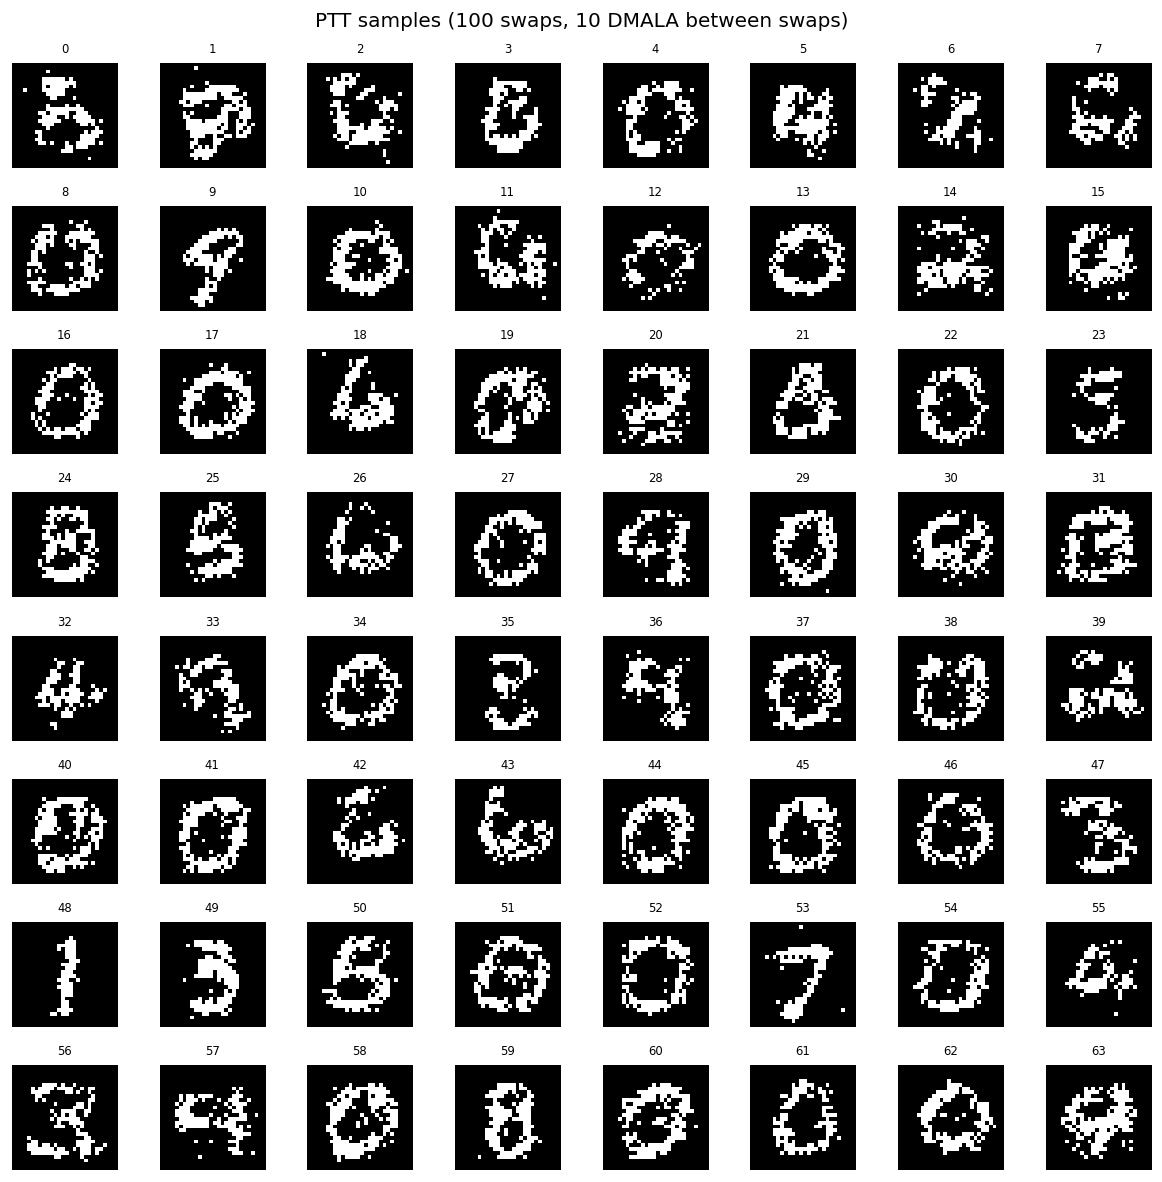

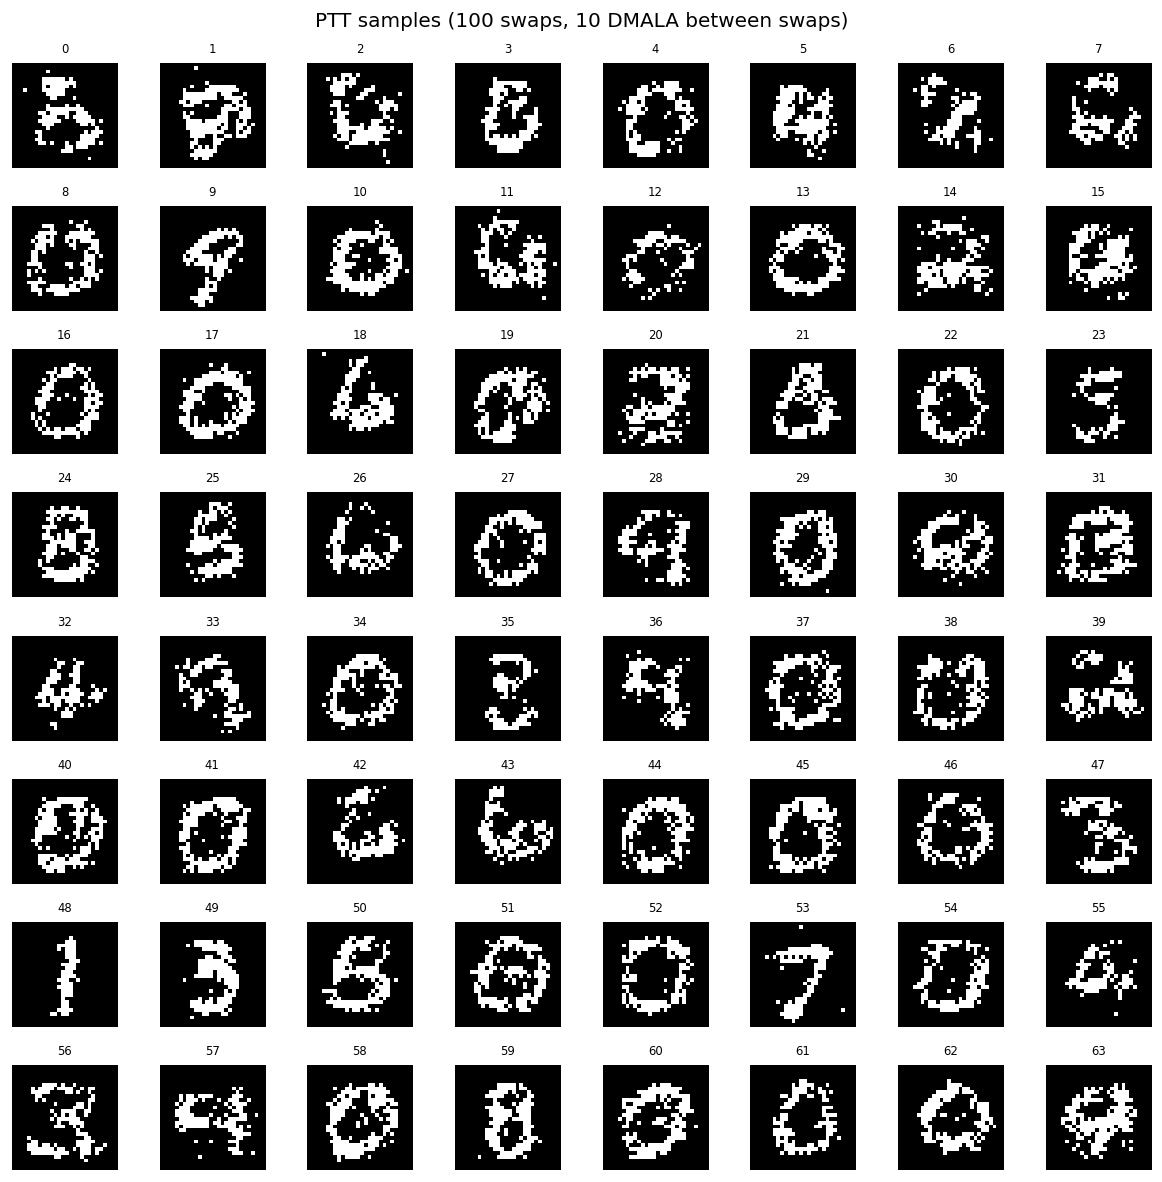

In [26]:
# Samples after additional PTT sampling
# This uses the saved PTT checkpoint ladder, not only classical DMALA.

import sys
from pathlib import Path
import torch

CODE_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "rbms" else Path.cwd().resolve()
PTT_REPO = CODE_ROOT / "ptt-bebm"

if str(PTT_REPO) not in sys.path:
    sys.path.insert(0, str(PTT_REPO))

from ptt import sample_from_file

PTT_NUM_SAMPLES = 64
PTT_NUM_SWAP_ROUNDS = 100
PTT_LOCAL_DMALA_STEPS = 10
PTT_INIT_STEPS = 100

sampler_ptt, ptt_updates = sample_from_file(
    filename=str(filename),
    n_gen=PTT_NUM_SAMPLES,
    device=device,
    dtype=dtype,
    n_steps=PTT_NUM_SWAP_ROUNDS,
    increment=PTT_LOCAL_DMALA_STEPS,
    n_steps_init=PTT_INIT_STEPS,
    use_all_updates=False,
    append_last_model=True,
)

ptt_samples = sampler_ptt.get_chains(-1)["visible"].detach().cpu().numpy()

print("PTT repo:", PTT_REPO)
print("PTT updates:", ptt_updates)
print("PTT samples shape:", ptt_samples.shape)
print("PTT acceptance rates:", sampler_ptt.acc_rates.detach().cpu().numpy())

plot_image_grid(
    ptt_samples,
    title=(
        f"PTT samples "
        f"({PTT_NUM_SWAP_ROUNDS} swaps, "
        f"{PTT_LOCAL_DMALA_STEPS} DMALA between swaps)"
    ),
    cmap="gray",
)


## W1, b1 and singular values over training

W1 shape: (500, 784)
b1 shape: (500,)
W1 mean/std: -0.001811030670069158 0.03389820083975792
b1 mean/std/min/max: 0.06310277432203293 0.463110089302063 -7.387264728546143 4.073176860809326


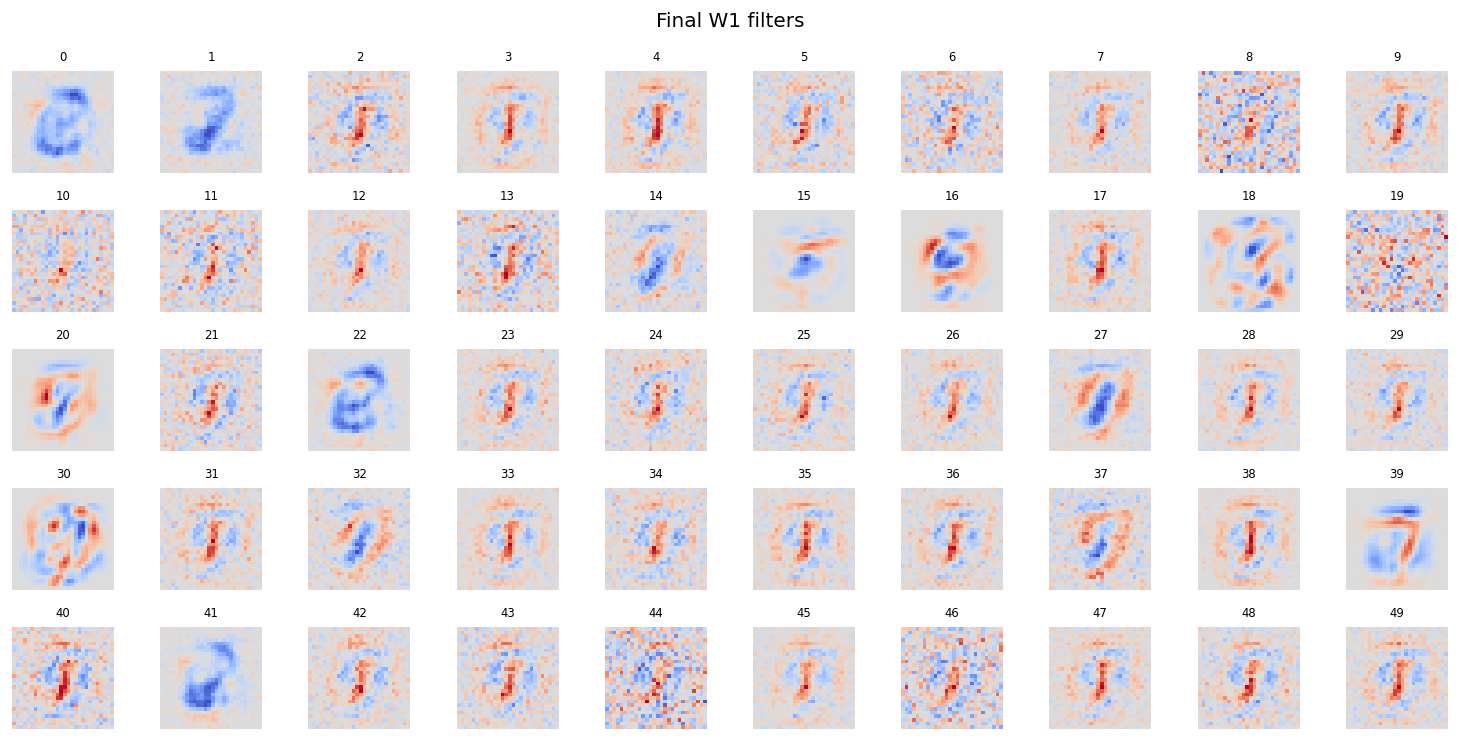

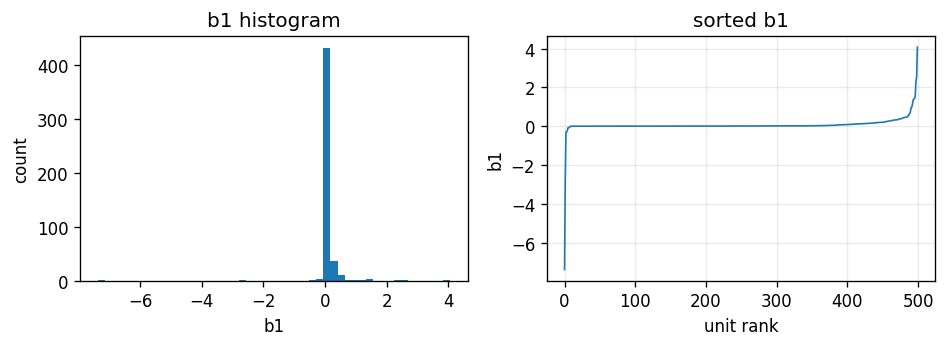

In [27]:
w1, b1 = get_w1_b1(params)
print("W1 shape:", w1.shape)
print("b1 shape:", b1.shape)
print("W1 mean/std:", float(w1.mean()), float(w1.std()))
print("b1 mean/std/min/max:", float(b1.mean()), float(b1.std()), float(b1.min()), float(b1.max()))

plot_image_grid(w1, title="Final W1 filters", n_cols=10, max_items=50, cmap="coolwarm");

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(b1, bins=50)
axes[0].set_title("b1 histogram")
axes[0].set_xlabel("b1")
axes[0].set_ylabel("count")
axes[1].plot(np.sort(b1), linewidth=1)
axes[1].set_title("sorted b1")
axes[1].set_xlabel("unit rank")
axes[1].set_ylabel("b1")
axes[1].grid(alpha=0.25)
fig.tight_layout()

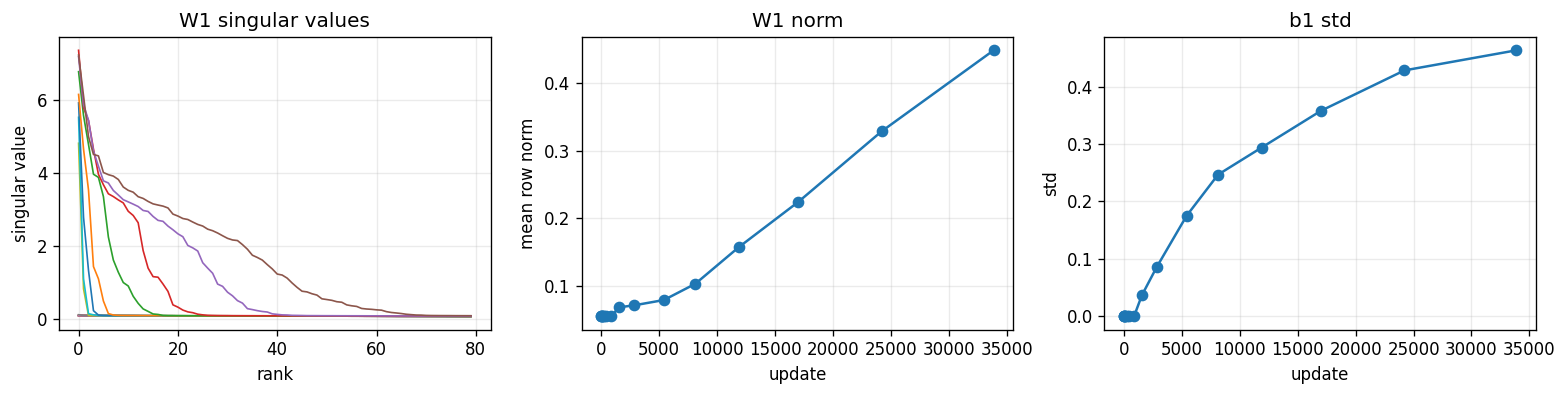

In [28]:
spectral_updates = saved_updates[np.linspace(0, len(saved_updates) - 1, min(16, len(saved_updates))).astype(int)]
spectra = []
w1_norms = []
b1_stds = []

for update in spectral_updates:
    p = load_params(str(filename), int(update), device=device, dtype=dtype)
    w, b = get_w1_b1(p)
    singular_values = np.linalg.svd(w - w.mean(axis=0, keepdims=True), compute_uv=False)
    spectra.append(singular_values)
    w1_norms.append(np.linalg.norm(w, axis=1).mean())
    b1_stds.append(b.std())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for update, singular_values in zip(spectral_updates, spectra):
    axes[0].plot(singular_values[:80], linewidth=1, label=str(int(update)))
axes[0].set_xlabel("rank")
axes[0].set_ylabel("singular value")
axes[0].set_title("W1 singular values")
axes[0].grid(alpha=0.25)

axes[1].plot(spectral_updates, w1_norms, marker="o")
axes[1].set_xlabel("update")
axes[1].set_ylabel("mean row norm")
axes[1].set_title("W1 norm")
axes[1].grid(alpha=0.25)

axes[2].plot(spectral_updates, b1_stds, marker="o")
axes[2].set_xlabel("update")
axes[2].set_ylabel("std")
axes[2].set_title("b1 std")
axes[2].grid(alpha=0.25)
fig.tight_layout()

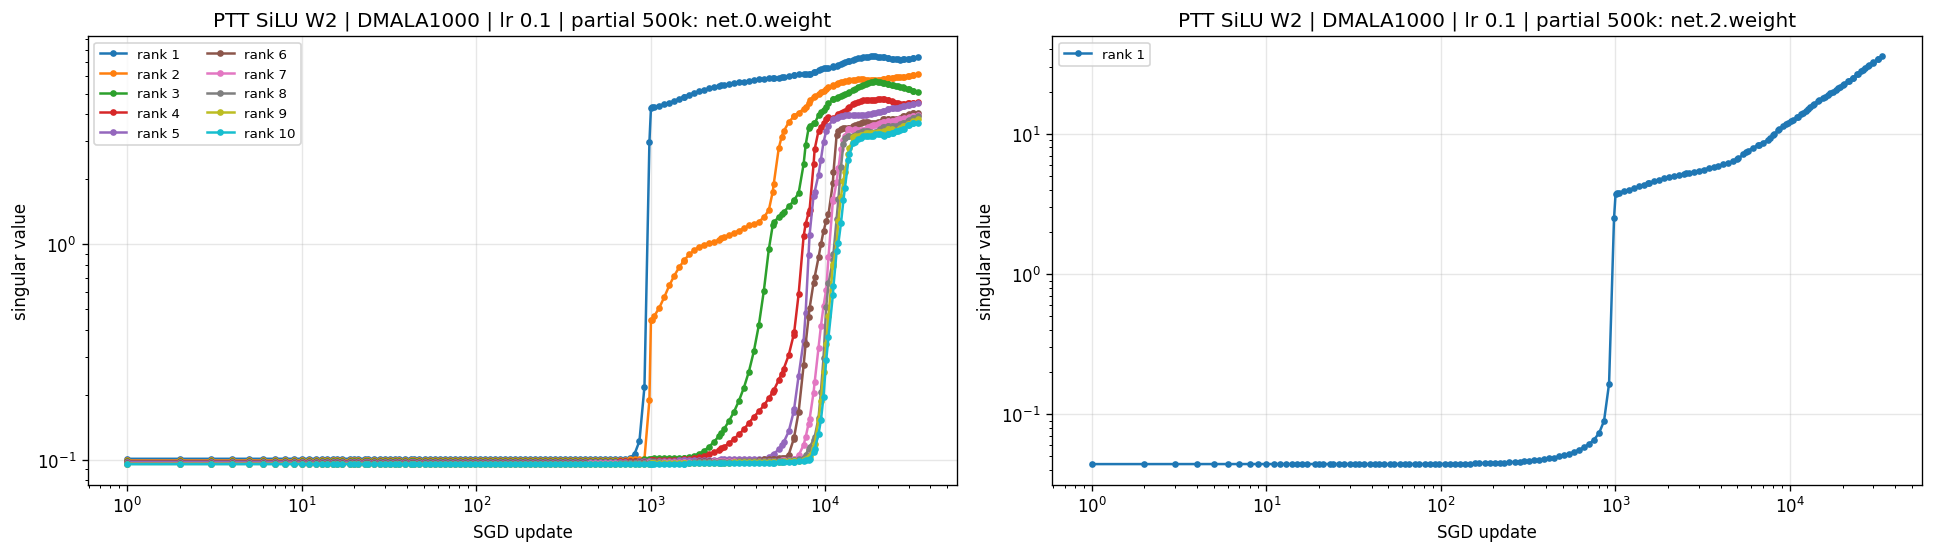

In [29]:
# Singular values of all saved MLP weight tensors.
# NoW2 archives only have net.0.weight; W2 archives also have net.2.weight.

top_k = 10
updates = []
sv_history = {}

with h5py.File(filename, "r") as f:
    update_names = sorted(
        [key for key in f.keys() if key.startswith("update_")],
        key=lambda name: int(name.split("_")[1]),
    )
    first_params = f[update_names[0]]["params"]
    weight_keys = sorted(
        [key for key in first_params.keys() if key.startswith("net.") and key.endswith(".weight")],
        key=lambda key: int(key.split(".")[1]),
    )
    sv_history = {key: [] for key in weight_keys}

    for update_name in update_names:
        update = int(update_name.split("_")[1])
        params_group = f[update_name]["params"]
        if not all(key in params_group for key in weight_keys):
            continue
        updates.append(update)
        for key in weight_keys:
            W = np.asarray(params_group[key])
            s = np.linalg.svd(W, compute_uv=False)
            sv_history[key].append(s[:top_k])

updates = np.asarray(updates)
fig, axes = plt.subplots(1, len(weight_keys), figsize=(8 * len(weight_keys), 4.5), constrained_layout=True, squeeze=False)

for ax, key in zip(axes.ravel(), weight_keys):
    sv = np.asarray(sv_history[key])
    n_modes = min(top_k, sv.shape[1])
    for mode in range(n_modes):
        ax.plot(updates, sv[:, mode], marker=".", linewidth=1.5, label=f"rank {mode + 1}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("SGD update")
    ax.set_ylabel("singular value")
    ax.set_title(f"{ACTIVE_RUN}: {key}")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

plt.show()


## Data PCA space: train/test/chains

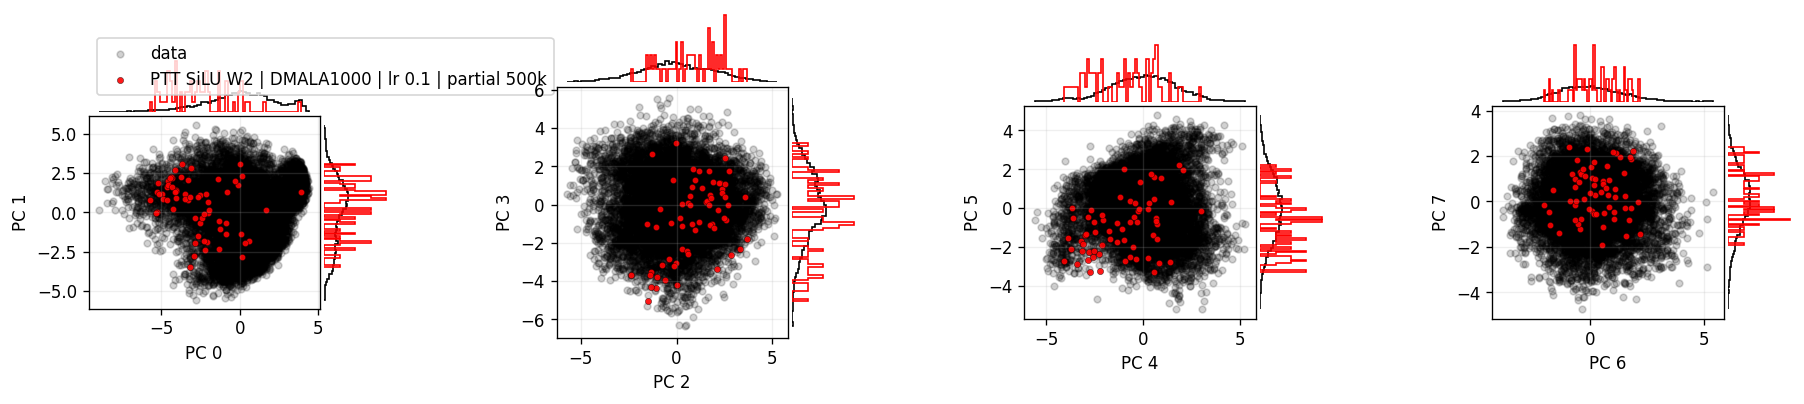

In [34]:
# PCA space for generated PTT samples, not final permanent chains.
# Black = data, red = generated samples from sample_from_file / PTT.

PCA_NUM_DATA = min(10000, train_data.shape[0])
PCA_PAIRS = [(0, 1), (2, 3), (4, 5), (6, 7)]

pca_data = train_data[:PCA_NUM_DATA]
pca_center = pca_data.mean(axis=0, keepdims=True)
_, _, pca_vt = np.linalg.svd(pca_data - pca_center, full_matrices=False)

def project_pca(x, n_components=8):
    return (x - pca_center) @ pca_vt[:n_components].T

data_proj = project_pca(pca_data, n_components=8)
gen_proj = project_pca(ptt_samples, n_components=8)

fig, axes = plt.subplots(1, len(PCA_PAIRS), figsize=(3.8 * len(PCA_PAIRS), 3.8))

if len(PCA_PAIRS) == 1:
    axes = [axes]

for ax, (pc_x, pc_y) in zip(axes, PCA_PAIRS):
    x_data = data_proj[:, pc_x]
    y_data = data_proj[:, pc_y]
    x_gen = gen_proj[:, pc_x]
    y_gen = gen_proj[:, pc_y]

    ax.scatter(
        x_data,
        y_data,
        s=16,
        c="black",
        alpha=0.18,
        label="data",
    )
    ax.scatter(
        x_gen,
        y_gen,
        s=14,
        c="red",
        edgecolors="black",
        linewidths=0.25,
        alpha=0.9,
        label=ACTIVE_RUN,
    )

    ax.set_xlabel(f"PC {pc_x}")
    ax.set_ylabel(f"PC {pc_y}")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)

    ax_top = ax.inset_axes([0.0, 1.02, 1.0, 0.28], sharex=ax)
    ax_top.hist(x_data, bins=60, histtype="step", color="black", density=True)
    ax_top.hist(x_gen, bins=60, histtype="step", color="red", density=True)
    ax_top.axis("off")

    ax_right = ax.inset_axes([1.02, 0.0, 0.28, 1.0], sharey=ax)
    ax_right.hist(y_data, bins=60, histtype="step", color="black", density=True, orientation="horizontal")
    ax_right.hist(y_gen, bins=60, histtype="step", color="red", density=True, orientation="horizontal")
    ax_right.axis("off")

axes[0].legend(loc="upper left", bbox_to_anchor=(0.0, 1.45), frameon=True)
plt.tight_layout()
plt.show()
